# 05. Advanced Models (Gradient Boosting)

Continuing from `cleaned_preprocessed_data.csv` (02_preprocessing.ipynb, including the Week 6 engineered features `BedBathRatio` / `PropertyAge` / `SchoolDistrictGIS`, with `Latitude`/`Longitude` excluded).

Here we try two gradient boosting implementations - **XGBoost** and **LightGBM** - do a light hyperparameter search over `max_depth` / `learning_rate` / `n_estimators` (plus `num_leaves` for LightGBM specifically - see section 4) for each, and report test-set metrics - including a like-for-like comparison against Linear Regression and Random Forest retrained on this exact same data, since `03_baseline_model.ipynb` / `04_model_comparison.ipynb` were built before the Week 6 feature set existed and shouldn't be assumed comparable until they're re-run.

**Note on tuning methodology**: earlier notebooks (e.g. the train-window search in 02_preprocessing.ipynb) picked their setting by checking directly against the test month. Here a proper validation split carved out of the training window is used for hyperparameter tuning instead, so the true test month stays untouched until the very last step (section 6).


In [53]:
import re
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
except ImportError as e:
    raise ImportError(
        "This notebook needs xgboost. Install with: pip install xgboost"
    ) from e

try:
    from lightgbm import LGBMRegressor
except ImportError as e:
    raise ImportError(
        "This notebook needs lightgbm. Install with: pip install lightgbm"
    ) from e

RANDOM_STATE = 42


## 1. Load cleaned dataset


In [54]:
cleaned_df = pd.read_csv("cleaned_preprocessed_data.csv", low_memory=False)
print(cleaned_df.shape)
cleaned_df["split"].value_counts()


(141988, 115)


split
train    129964
test      12024
Name: count, dtype: int64

In [55]:
cleaned_df[cleaned_df["ClosePrice"] <= 0]

,num__LivingArea,num__DaysOnMarket,num__ParkingTotal,num__LotSizeAcres,num__YearBuilt,num__BathroomsTotalInteger,num__BedroomsTotal,num__Stories,num__LotSizeArea,num__MainLevelBedrooms,...,cat__missingindicator_Levels_False,cat__missingindicator_Levels_True,cat__missingindicator_NewConstructionYN_False,cat__missingindicator_NewConstructionYN_True,cat__missingindicator_SchoolDistrictGIS_False,cat__missingindicator_SchoolDistrictGIS_True,ClosePrice,year_month,date,split


## 2. Separate features / target using the `split` column

Same pattern as 03_baseline_model.ipynb / 04_model_comparison.ipynb: `split == "train"` for training, `split == "test"` for the held-out final evaluation (the most recent month, never touched until section 6).

Feature column names are sanitized before use: several are one-hot columns from the multi-label `Flooring` encoding (02_preprocessing.ipynb section 5), e.g. `cat__Flooring_Bamboo,Carpet,Laminate`, and LightGBM's parser rejects feature names containing certain JSON special characters (`, : [ ] { } "`) - XGBoost happens to tolerate them, but they're replaced with `_` for both models here so the two stay on identical column names.


In [56]:
target = "ClosePrice"
meta_cols = [target, "date", "year_month", "split"]

def sanitize_feature_name(name):
    # LightGBM rejects these JSON special characters in feature names; XGBoost tolerates them,
    # but both models are kept on identical (sanitized) column names to avoid any mismatch.
    return re.sub(r'[",:\[\]{}]', "_", name)

raw_feature_cols = [c for c in cleaned_df.columns if c not in meta_cols]
sanitized_names = [sanitize_feature_name(c) for c in raw_feature_cols]

if len(set(sanitized_names)) != len(sanitized_names):
    # Extremely unlikely with this data, but guard against two different raw names colliding
    # onto the same sanitized name (e.g. "A,B" and "A:B" both becoming "A_B").
    seen = {}
    deduped = []
    for name in sanitized_names:
        seen[name] = seen.get(name, 0) + 1
        deduped.append(name if seen[name] == 1 else f"{name}_{seen[name]}")
    sanitized_names = deduped

cleaned_df = cleaned_df.rename(columns=dict(zip(raw_feature_cols, sanitized_names)))
feature_cols = sanitized_names

train_df = cleaned_df[cleaned_df["split"] == "train"].copy()
test_df = cleaned_df[cleaned_df["split"] == "test"].copy()

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")


X_train: (129964, 111) | X_test: (12024, 111)


## 3. Carve out a validation split from the training window (for tuning only)

The last month inside the training window is held out as a validation month; hyperparameter combinations are scored against it in section 4. The true test month (section 2) is never used until the single final evaluation in section 6.


In [57]:
months_in_train = sorted(train_df["year_month"].unique())
val_month = months_in_train[-1]
tune_train_months = months_in_train[:-1]

tune_train_df = train_df[train_df["year_month"].isin(tune_train_months)]
tune_val_df = train_df[train_df["year_month"] == val_month]

X_tune_train = tune_train_df[feature_cols]
y_tune_train = tune_train_df[target]

X_tune_val = tune_val_df[feature_cols]
y_tune_val = tune_val_df[target]

print(f"Tuning train months: {tune_train_months}")
print(f"Validation month: {val_month}")
print(f"X_tune_train: {X_tune_train.shape} | X_tune_val: {X_tune_val.shape}")


Tuning train months: ['2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03']
Validation month: 2026-04
X_tune_train: (117933, 111) | X_tune_val: (12031, 111)


## 4. Light hyperparameter search

A small grid over `max_depth`, `learning_rate`, `n_estimators` for both models (3 × 2 × 2 = 12 combinations each). **LightGBM also gets `num_leaves` in its grid**: LightGBM grows trees *leaf-wise* rather than XGBoost's default *depth-wise* growth, and its actual tree complexity is controlled mainly by `num_leaves` (default 31) - `max_depth` alone is more of a safety cap. Tuning `max_depth` without also tuning `num_leaves` means LightGBM's real complexity barely changes between settings, which isn't a fair comparison against XGBoost. `num_leaves` candidates are kept under `2^max_depth` for each depth, matching LightGBM's own tuning guidance.

Each combination is fit on `tune_train` and scored on `tune_val` only (`verbose=-1` just silences LightGBM's per-iteration logging - it doesn't affect the fit).


In [58]:
MAX_DEPTH_CANDIDATES = [3, 5, 7]
LEARNING_RATE_CANDIDATES = [0.05, 0.1]
N_ESTIMATORS_CANDIDATES = [200, 400]

# LightGBM-only: num_leaves candidates per max_depth, kept under 2^max_depth so tree complexity
# actually tracks max_depth instead of being dominated by LightGBM's num_leaves=31 default.
LGBM_NUM_LEAVES_BY_DEPTH = {3: [7], 5: [15, 31], 7: [31, 63]}

GBM_CONSTRUCTORS = {
    "XGBoost": lambda **params: XGBRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1),
    "LightGBM": lambda **params: LGBMRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}


def xgb_param_combinations():
    for max_depth, learning_rate, n_estimators in itertools.product(
        MAX_DEPTH_CANDIDATES, LEARNING_RATE_CANDIDATES, N_ESTIMATORS_CANDIDATES
    ):
        yield {"max_depth": max_depth, "learning_rate": learning_rate, "n_estimators": n_estimators}


def lgbm_param_combinations():
    for max_depth in MAX_DEPTH_CANDIDATES:
        for num_leaves in LGBM_NUM_LEAVES_BY_DEPTH[max_depth]:
            for learning_rate, n_estimators in itertools.product(LEARNING_RATE_CANDIDATES, N_ESTIMATORS_CANDIDATES):
                yield {
                    "max_depth": max_depth,
                    "num_leaves": num_leaves,
                    "learning_rate": learning_rate,
                    "n_estimators": n_estimators,
                }


GBM_PARAM_GENERATORS = {"XGBoost": xgb_param_combinations, "LightGBM": lgbm_param_combinations}

tuning_results = []

for gbm_name, constructor in GBM_CONSTRUCTORS.items():
    for params in GBM_PARAM_GENERATORS[gbm_name]():
        model = constructor(**params)
        model.fit(X_tune_train, y_tune_train)
        pred = model.predict(X_tune_val)

        result_row = {"gbm": gbm_name, **params}
        result_row["val_R2"] = r2_score(y_tune_val, pred)
        result_row["val_MAE"] = mean_absolute_error(y_tune_val, pred)
        result_row["val_RMSE"] = np.sqrt(mean_squared_error(y_tune_val, pred))  # squared=False was removed in newer sklearn, so use sqrt instead
        tuning_results.append(result_row)

        param_str = " | ".join(f"{k}={v}" for k, v in params.items())
        print(f"[{gbm_name:>8} | {param_str}] val_R2={result_row['val_R2']:.4f} | val_RMSE={result_row['val_RMSE']:,.0f}")


[ XGBoost | max_depth=3 | learning_rate=0.05 | n_estimators=200] val_R2=0.0114 | val_RMSE=11,693,203
[ XGBoost | max_depth=3 | learning_rate=0.05 | n_estimators=400] val_R2=0.0090 | val_RMSE=11,707,673
[ XGBoost | max_depth=3 | learning_rate=0.1 | n_estimators=200] val_R2=0.0083 | val_RMSE=11,711,924
[ XGBoost | max_depth=3 | learning_rate=0.1 | n_estimators=400] val_R2=-0.0058 | val_RMSE=11,794,997
[ XGBoost | max_depth=5 | learning_rate=0.05 | n_estimators=200] val_R2=0.0084 | val_RMSE=11,711,214
[ XGBoost | max_depth=5 | learning_rate=0.05 | n_estimators=400] val_R2=0.0036 | val_RMSE=11,739,584
[ XGBoost | max_depth=5 | learning_rate=0.1 | n_estimators=200] val_R2=-0.0029 | val_RMSE=11,777,478
[ XGBoost | max_depth=5 | learning_rate=0.1 | n_estimators=400] val_R2=-0.0205 | val_RMSE=11,880,394
[ XGBoost | max_depth=7 | learning_rate=0.05 | n_estimators=200] val_R2=-0.0057 | val_RMSE=11,794,402
[ XGBoost | max_depth=7 | learning_rate=0.05 | n_estimators=400] val_R2=-0.0137 | val_RMSE=

## 5. Validation results

`num_leaves` is `NaN` for every XGBoost row (it doesn't use that hyperparameter) - expected, not a bug.


In [59]:
tuning_results_df = pd.DataFrame(tuning_results).sort_values("val_RMSE").reset_index(drop=True)
tuning_results_df.to_csv("advanced_model_tuning_results.csv", index=False)
print("Saved advanced_model_tuning_results.csv")

print("Best configuration per model (by validation RMSE):")
best_per_gbm = tuning_results_df.sort_values("val_RMSE").groupby("gbm", as_index=False).first()
display(best_per_gbm)

tuning_results_df


Saved advanced_model_tuning_results.csv
Best configuration per model (by validation RMSE):


,gbm,max_depth,learning_rate,n_estimators,val_R2,val_MAE,val_RMSE,num_leaves
0,LightGBM,3,0.05,200,0.007246,702963.798929,1.171799e+07,7.0
1,XGBoost,3,0.05,200,0.011441,673750.981252,1.169320e+07,NaN


,gbm,max_depth,learning_rate,n_estimators,val_R2,val_MAE,val_RMSE,num_leaves
0,XGBoost,3,0.05,200,0.011441,673750.981252,1.169320e+07,NaN
1,XGBoost,3,0.05,400,0.008993,673089.332941,1.170767e+07,NaN
2,XGBoost,5,0.05,200,0.008393,660471.589127,1.171121e+07,NaN
3,XGBoost,3,0.10,200,0.008273,675241.013183,1.171192e+07,NaN
4,LightGBM,3,0.05,200,0.007246,702963.798929,1.171799e+07,7.0
5,LightGBM,5,0.05,200,0.006095,695285.935109,1.172478e+07,15.0
6,LightGBM,5,0.05,200,0.005586,695817.370047,1.172778e+07,31.0
7,LightGBM,3,0.05,400,0.004939,706510.753075,1.173159e+07,7.0
8,LightGBM,3,0.10,200,0.004581,710641.764819,1.173371e+07,7.0
9,LightGBM,5,0.10,200,0.003737,712617.699282,1.173868e+07,31.0


## 6. Retrain the best configuration of each model on the full training window & evaluate on the true test month

The winning hyperparameters (lowest `val_RMSE`) *for each of XGBoost and LightGBM separately* are refit on the **entire** training window (`X_train`/`y_train`, i.e. `tune_train` + the validation month combined) - the validation split was only a tool for picking hyperparameters, so the final models shouldn't be trained on less data than necessary. Both are evaluated against the true test month exactly once.


In [60]:
PARAM_COLUMNS = ["max_depth", "num_leaves", "learning_rate", "n_estimators"]
INT_PARAMS = {"max_depth", "num_leaves", "n_estimators"}


def extract_params(row):
    params = {}
    for col in PARAM_COLUMNS:
        val = row.get(col)
        if pd.notna(val):
            params[col] = int(val) if col in INT_PARAMS else float(val)
    return params


gbm_best_params = {}
gbm_models = {}
gbm_test_metrics = {}

for gbm_name in GBM_CONSTRUCTORS:
    best_row = tuning_results_df[tuning_results_df["gbm"] == gbm_name].sort_values("val_RMSE").iloc[0]
    params = extract_params(best_row)
    gbm_best_params[gbm_name] = params
    print(f"Best {gbm_name} hyperparameters (by validation RMSE): {params}")

    model = GBM_CONSTRUCTORS[gbm_name](**params)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    gbm_models[gbm_name] = model
    gbm_test_metrics[gbm_name] = {
        "R2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
    }

    metrics = gbm_test_metrics[gbm_name]
    print(f"{gbm_name} (tuned) - R2: {metrics['R2']:.4f} | MAE: {metrics['MAE']:,.0f} | RMSE: {metrics['RMSE']:,.0f}\n")

xgb_model, lgbm_model = gbm_models["XGBoost"], gbm_models["LightGBM"]
xgb_test_metrics, lgbm_test_metrics = gbm_test_metrics["XGBoost"], gbm_test_metrics["LightGBM"]


Best XGBoost hyperparameters (by validation RMSE): {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 200}
XGBoost (tuned) - R2: 0.2824 | MAE: 508,814 | RMSE: 1,421,509

Best LightGBM hyperparameters (by validation RMSE): {'max_depth': 3, 'num_leaves': 7, 'learning_rate': 0.05, 'n_estimators': 200}
LightGBM (tuned) - R2: 0.0062 | MAE: 521,955 | RMSE: 1,672,845



## 7. Feature importance

XGBoost and LightGBM don't necessarily agree on which features matter most, even when both are gradient-boosted trees on the same data - comparing the two side by side shows how much (or little) that differs.


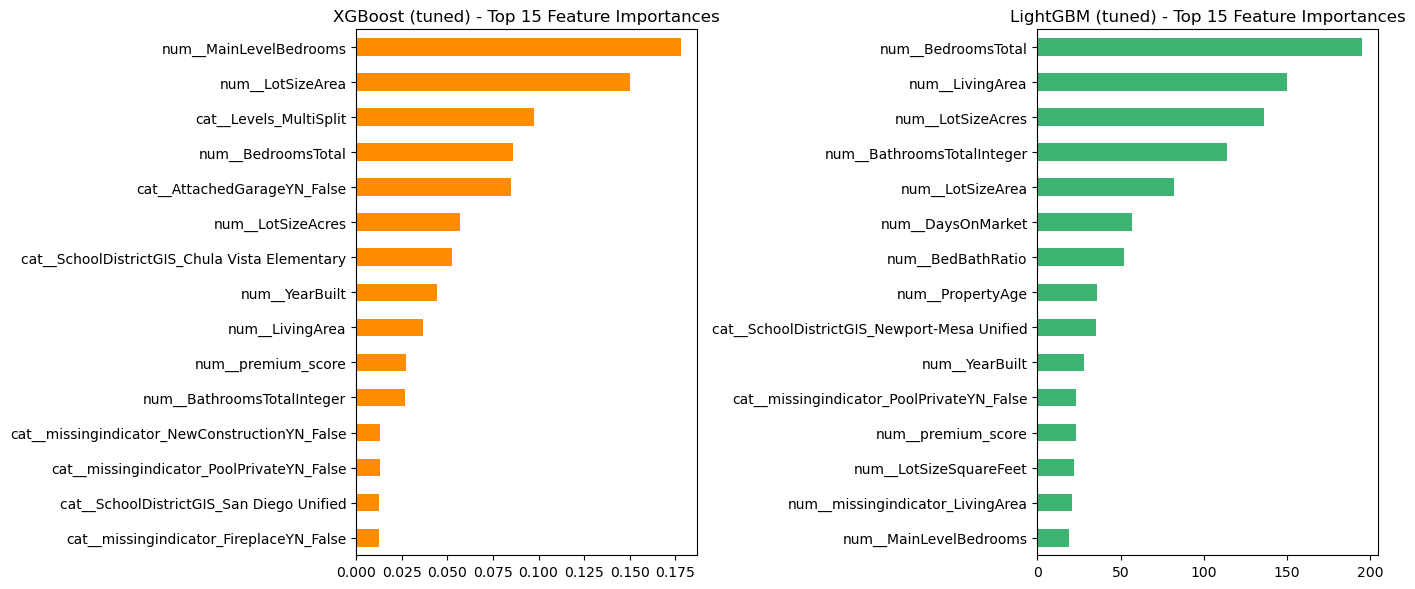

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

xgb_importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
xgb_importances.head(15).sort_values().plot(kind="barh", ax=axes[0], color="darkorange")
axes[0].set_title("XGBoost (tuned) - Top 15 Feature Importances")

lgbm_importances = pd.Series(lgbm_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
lgbm_importances.head(15).sort_values().plot(kind="barh", ax=axes[1], color="mediumseagreen")
axes[1].set_title("LightGBM (tuned) - Top 15 Feature Importances")

plt.tight_layout()
plt.show()


## 8. Compare against Linear Regression and Random Forest & record results

`LinearRegression` and `RandomForestRegressor (max_depth=5)` (the most stable Random Forest setting found in 04_model_comparison.ipynb) are retrained here on the exact same `X_train`/`X_test` used for the gradient boosting models above, rather than reusing `baseline_model_results.csv` / `model_comparison_results.csv` - those were generated before the Week 6 feature set existed, so pulling numbers from them here could compare the new models against ones trained on a different set of columns.


In [62]:
def evaluate(model, X, y):
    pred = model.predict(X)
    return {
        "R2": r2_score(y, pred),
        "MAE": mean_absolute_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
    }

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_test_metrics = evaluate(linear_model, X_test, y_test)

forest_model = RandomForestRegressor(max_depth=5, random_state=RANDOM_STATE, n_jobs=-1)
forest_model.fit(X_train, y_train)
forest_test_metrics = evaluate(forest_model, X_test, y_test)

advanced_model_results = pd.DataFrame([
    {"model": "LinearRegression", **linear_test_metrics},
    {"model": "RandomForest (max_depth=5)", **forest_test_metrics},
    {"model": f"XGBoost (tuned: {gbm_best_params['XGBoost']})", **xgb_test_metrics},
    {"model": f"LightGBM (tuned: {gbm_best_params['LightGBM']})", **lgbm_test_metrics},
])
advanced_model_results["n_train_rows"] = len(X_train)
advanced_model_results["n_test_rows"] = len(X_test)
advanced_model_results = advanced_model_results[["model", "n_train_rows", "n_test_rows", "R2", "MAE", "RMSE"]]
advanced_model_results = advanced_model_results.sort_values("R2", ascending=False).reset_index(drop=True)

advanced_model_results.to_csv("advanced_model_results.csv", index=False)
print("Saved advanced_model_results.csv")
advanced_model_results


Saved advanced_model_results.csv


,model,n_train_rows,n_test_rows,R2,MAE,RMSE
0,LinearRegression,129964,12024,0.336487,547257.189138,1.366886e+06
1,"XGBoost (tuned: {'max_depth': 3, 'learning_rat...",129964,12024,0.282397,508814.009145,1.421509e+06
2,RandomForest (max_depth=5),129964,12024,0.028292,593513.496416,1.654152e+06
3,"LightGBM (tuned: {'max_depth': 3, 'num_leaves'...",129964,12024,0.006207,521954.762619,1.672845e+06


## Summary

- Models: `XGBRegressor` and `LGBMRegressor`, each tuned via its own light grid search scored on a validation month carved out of the training window, not the true test month. XGBoost's grid is `max_depth` × `learning_rate` × `n_estimators` (12 combinations); LightGBM's also includes `num_leaves` (20 combinations, candidates kept under `2^max_depth` per depth) - see section 4 for why `num_leaves` matters for LightGBM specifically (it controls tree complexity more directly than `max_depth` does, since LightGBM grows trees leaf-wise)
- Feature names are sanitized before fitting (section 2) since several one-hot columns from the multi-label `Flooring` encoding contain commas, which LightGBM's parser rejects (`"Do not support special JSON characters in feature name"`) - both models are kept on identical sanitized names
- The winning configuration for each (section 6, `gbm_best_params`) is refit on the full training window and evaluated once on the true test month - see section 6's printed R² / MAE / RMSE, and `advanced_model_tuning_results.csv` for the full validation grid (both models, tagged by the `gbm` column; `num_leaves` is `NaN` for XGBoost rows)
- Section 8 places both gradient boosting models side-by-side with `LinearRegression` and `RandomForest (max_depth=5)`, all four retrained on the identical Week-6 feature set / train-test split, so the comparison in `advanced_model_results.csv` is apples-to-apples and doesn't rely on potentially stale results from 03_baseline_model.ipynb / 04_model_comparison.ipynb
- Feature importance (section 7) compares which features XGBoost vs. LightGBM each rely on most, alongside the Random Forest importances from 04_model_comparison.ipynb / 02_preprocessing.ipynb
- Deliverables: `advanced_model_tuning_results.csv` (validation grid for both models), `advanced_model_results.csv` (final test metrics: Linear Regression, Random Forest, XGBoost, LightGBM), this notebook (`05_advanced_models.ipynb`)
